# Regression models: Prediction

We are now gonna compare how the parsimonious model perfroms against the stepwise model.

In [2]:
import sys
sys.path.append("..")
from src.models.regression.prediction import run_regression_model_comparison

import pandas as pd

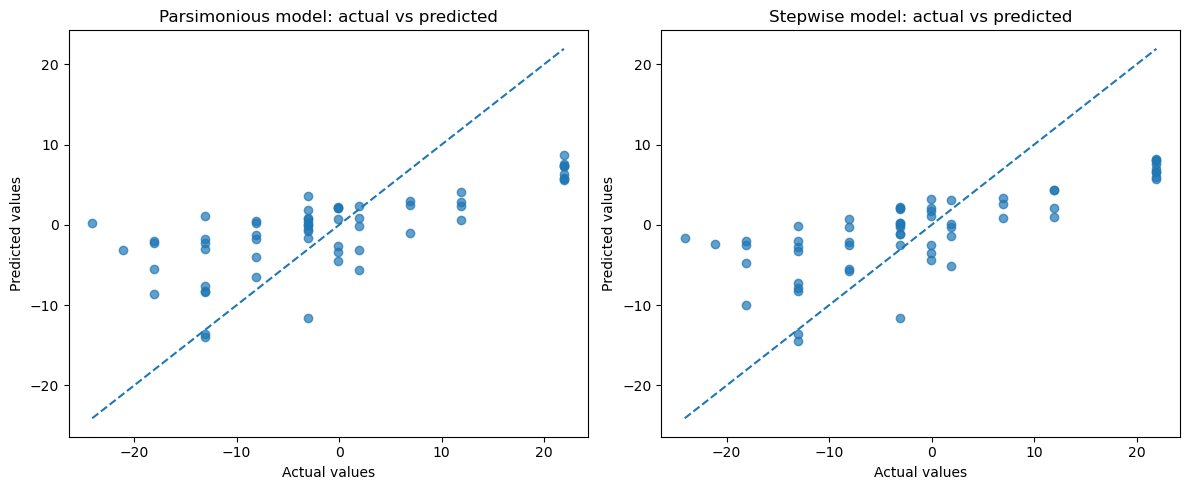

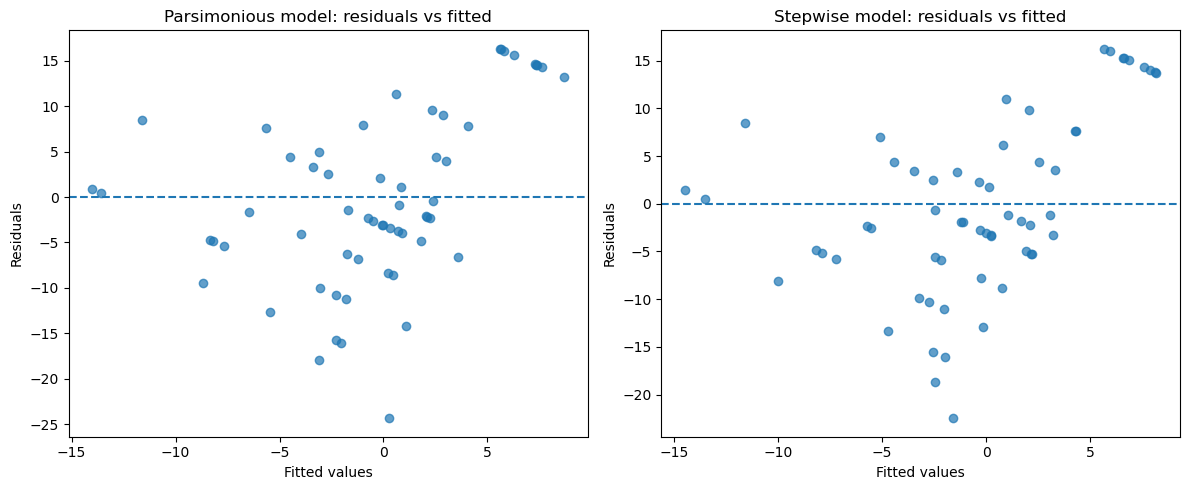

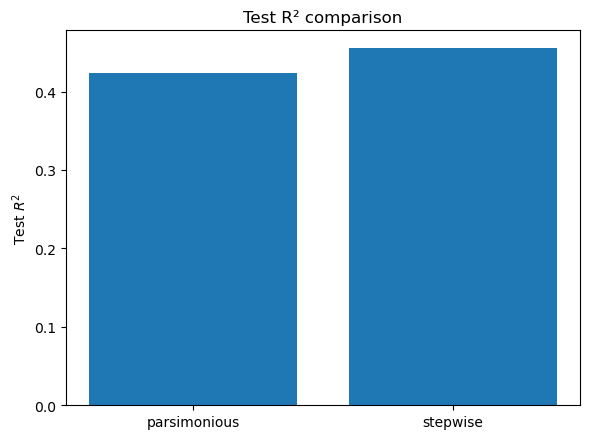

,model,split,n_features,features,r2,mae,mse,rmse
0,parsimonious,train,3,"ejection_creatinine_interaction, creatinine_lo...",0.464112,6.369220,72.442120,8.511294
1,parsimonious,test,3,"ejection_creatinine_interaction, creatinine_lo...",0.423756,7.699951,90.200690,9.497404
2,stepwise,train,5,"age_centered, creatinine_log, ejection_creatin...",0.470495,6.342329,71.579295,8.460455
3,stepwise,test,5,"age_centered, creatinine_log, ejection_creatin...",0.455224,7.470016,85.275009,9.234447


                                OLS Regression Results                                
Dep. Variable:     ejection_fraction_centered   R-squared:                       0.464
Model:                                    OLS   Adj. R-squared:                  0.457
Method:                         Least Squares   F-statistic:                     67.84
Date:                        Mon, 16 Mar 2026   Prob (F-statistic):           1.23e-31
Time:                                01:51:32   Log-Likelihood:                -850.92
No. Observations:                         239   AIC:                             1710.
Df Residuals:                             235   BIC:                             1724.
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [3]:
df_processed = pd.read_csv("../data/processed/heart_failure_clinical_records_dataset_processed.csv")

results = run_regression_model_comparison(
    df_processed,
    parsimonious_features=[
        "ejection_creatinine_interaction",
        "creatinine_log",
        "sodium_creatinine_interaction",
    ],
    stepwise_features=[
        "age_centered",
        "creatinine_log",
        "ejection_creatinine_interaction",
        "sodium_creatinine_interaction",
        "serum_sodium",
    ],
)
display(results["metrics_table"])

print(results["parsimonious"]["train_summary"])
print(results["stepwise"]["train_summary"])

Two regression specifications were evaluated: a parsimonious model
containing three predictors and a stepwise-selected model containing
five predictors.

The stepwise model achieved slightly better predictive performance,
with a test R² of approximately 0.46 compared to 0.42 for the parsimonious
model.

Importantly, the train and test performance are similar for both models,
suggesting that overfitting is limited.

These results indicate that the engineered features capture meaningful
structure in the data, allowing the model to explain roughly 45% of the
variance in the target variable.

The predicted vs actual plots show that both regression models capture
the general trend of the data, with predictions roughly aligned along
the identity line. However, noticeable dispersion around the diagonal
indicates that prediction errors remain substantial.

The stepwise model exhibits slightly tighter clustering around the
identity line, consistent with its higher test R².

Residual diagnostics reveal a roughly centered distribution around zero,
although some structure is visible in the residuals, suggesting that
linear models may not fully capture the underlying relationships.

These results indicate that while the linear models capture meaningful
signal, additional model flexibility could potentially improve predictive
performance.